<a href="https://colab.research.google.com/github/SAINIDHI2005/IDS_GNN_Repo/blob/main/graphSAGE/HostFlowTemporal_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.8 MB/s eta 0:00:00


In [3]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [4]:
import os
import pandas as pd
DATASET_DIR = "/content/drive/MyDrive/CIC_IoT_2023/New_Disjoint_200K"


dfs = []

# -------------------------
# BENIGN
# -------------------------

benign = pd.read_csv(
    os.path.join(DATASET_DIR, "Benign_100K.csv")
)

benign = benign.iloc[:90000].copy()

benign["attack_type"] = "BENIGN"
benign["label"] = 0

dfs.append(benign)

# -------------------------
# DDOS
# -------------------------

ddos = pd.read_csv(
    os.path.join(DATASET_DIR, "DDoS_20K.csv")
)

ddos = ddos.iloc[:2000].copy()

ddos["attack_type"] = "DDoS_20K"
ddos["label"] = 1

dfs.append(ddos)

# -------------------------
# DOS
# -------------------------

dos = pd.read_csv(
    os.path.join(DATASET_DIR, "DoS_20K.csv")
)

dos = dos.iloc[:2000].copy()

dos["attack_type"] = "DoS_20K"
dos["label"] = 1

dfs.append(dos)

# -------------------------
# MIRAI
# -------------------------

mirai = pd.read_csv(
    os.path.join(DATASET_DIR, "Mirai_20K.csv")
)

mirai = mirai.iloc[:2000].copy()

mirai["attack_type"] = "Mirai_20K"
mirai["label"] = 1

dfs.append(mirai)

# -------------------------
# RECON
# -------------------------

recon = pd.read_csv(
    os.path.join(DATASET_DIR, "Recon_20K.csv")
)

recon = recon.iloc[:2000].copy()

recon["attack_type"] = "Recon_20K"
recon["label"] = 1

dfs.append(recon)

# -------------------------
# SPOOFING
# -------------------------

spoof = pd.read_csv(
    os.path.join(DATASET_DIR, "Spoofing_20K.csv")
)

spoof = spoof.iloc[:2000].copy()

spoof["attack_type"] = "Spoofing_20K"
spoof["label"] = 1

dfs.append(spoof)

# -------------------------
# COMBINE
# -------------------------

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

print("\nAttack Distribution:\n")
print(data["attack_type"].value_counts())

(100000, 88)

Attack Distribution:

attack_type
BENIGN          90000
DDoS_20K         2000
DoS_20K          2000
Mirai_20K        2000
Recon_20K        2000
Spoofing_20K     2000
Name: count, dtype: int64


In [5]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(100000, 89)


In [6]:
attack_type_backup = data["attack_type"].copy()

In [7]:
DROP_COLS = [

    "id",
    "expiration_id",

    "src_ip",
    "dst_ip",


   # "dst_port",
    #"src_port",
    #"protocol",
   # "ip_version"

    "src_mac",
    "dst_mac",

    "src_oui",
    "dst_oui",

    "requested_server_name",

    "client_fingerprint",
    "server_fingerprint",

    "user_agent",
    "content_type",

    "application_name",
    "application_category_name",

    "flow_id",
    "label",
    "attack_type",

    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",

    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",

    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",

    "application_confidence",
    "application_is_guessed",

    "vlan_id",
    "tunnel_id",

    "bidirectional_urg_packets",
    "src2dst_urg_packets",
    "dst2src_urg_packets",

    "dst2src_cwr_packets",
    "dst2src_ece_packets",

    "src_port",

    "bidirectional_duration_ms",
    "bidirectional_packets",

    "src2dst_packets",
    "dst2src_packets",

    "dst2src_min_ps",
    "dst2src_mean_ps",

    "bidirectional_min_piat_ms",
    "bidirectional_stddev_piat_ms",

    "dst2src_min_piat_ms",
    "dst2src_mean_piat_ms",
    "dst2src_max_piat_ms",

    "bidirectional_ece_packets",
    "bidirectional_psh_packets",
    "bidirectional_fin_packets",

    "src2dst_syn_packets",
    "src2dst_cwr_packets",
    "src2dst_ack_packets",
    "src2dst_rst_packets",
    "src2dst_fin_packets",

    "src2dst_mean_piat_ms",
    "src2dst_stddev_ps",

    "dst2src_ack_packets",
    "dst2src_psh_packets",
    "dst2src_rst_packets",
    "dst2src_fin_packets",

]

feature_cols = [

    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:",len(feature_cols))

Features: 30


In [8]:
feature_cols = [
    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:", len(feature_cols))

print("\nRetained Features:\n")
for i, f in enumerate(feature_cols, start=1):
    print(f"{i:2d}. {f}")

Features: 30

Retained Features:

 1. dst_port
 2. protocol
 3. ip_version
 4. bidirectional_bytes
 5. src2dst_duration_ms
 6. src2dst_bytes
 7. dst2src_duration_ms
 8. dst2src_bytes
 9. bidirectional_min_ps
10. bidirectional_mean_ps
11. bidirectional_stddev_ps
12. bidirectional_max_ps
13. src2dst_min_ps
14. src2dst_mean_ps
15. src2dst_max_ps
16. dst2src_stddev_ps
17. dst2src_max_ps
18. bidirectional_mean_piat_ms
19. bidirectional_max_piat_ms
20. src2dst_min_piat_ms
21. src2dst_stddev_piat_ms
22. src2dst_max_piat_ms
23. dst2src_stddev_piat_ms
24. bidirectional_syn_packets
25. bidirectional_cwr_packets
26. bidirectional_ack_packets
27. bidirectional_rst_packets
28. src2dst_ece_packets
29. src2dst_psh_packets
30. dst2src_syn_packets


In [9]:
top30 = {
    "bidirectional_mean_ps",
    "dst2src_syn_packets",
    "src2dst_min_ps",
    "ip_version",
    "src2dst_max_piat_ms",
    "dst2src_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_rst_packets",
    "src2dst_max_ps",
    "src2dst_duration_ms",
    "src2dst_bytes",
    "src2dst_ece_packets",
    "bidirectional_max_ps",
    "dst2src_bytes",
    "bidirectional_bytes",
    "dst2src_max_ps",
    "bidirectional_min_ps",
    "bidirectional_syn_packets",
    "dst2src_stddev_ps",
    "bidirectional_ack_packets",
    "protocol",
    "dst_port",
    "bidirectional_mean_piat_ms",
    "dst2src_duration_ms",
    "src2dst_mean_ps",
    "src2dst_min_piat_ms",
    "bidirectional_stddev_ps",
    "src2dst_stddev_piat_ms",
    "bidirectional_cwr_packets",
    "src2dst_psh_packets"
}

retained = set(feature_cols)

print("Missing from retained:")
print(sorted(top30 - retained))

print("\nExtra retained features:")
print(sorted(retained - top30))

Missing from retained:
[]

Extra retained features:
[]


In [10]:
for col in feature_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[feature_cols] = (
    data[feature_cols]
    .fillna(0)
)

In [11]:
import joblib

scaler = joblib.load(
    r"/content/drive/MyDrive/CIC_IoT_2023/Saved_Model/HostFlowTemporal_scaler_imp.pkl"
)

X = scaler.transform(
    data[feature_cols]
)

print(X.shape)

(100000, 30)


In [12]:
all_hosts = pd.concat(
    [
        data["src_ip"],
        data["dst_ip"]
    ]
).unique()

host_to_id = {

    host : idx + len(data)

    for idx,host
    in enumerate(all_hosts)
}

num_flow_nodes = len(data)

num_host_nodes = len(all_hosts)

print("Flow Nodes:",num_flow_nodes)
print("Host Nodes:",num_host_nodes)

Flow Nodes: 100000
Host Nodes: 1767


In [13]:
edges = []

for flow_id,row in data.iterrows():

    src_host = host_to_id[
        row["src_ip"]
    ]

    dst_host = host_to_id[
        row["dst_ip"]
    ]

    edges.append(
        [flow_id,src_host]
    )

    edges.append(
        [src_host,flow_id]
    )

    edges.append(
        [flow_id,dst_host]
    )

    edges.append(
        [dst_host,flow_id]
    )

print("Host-flow edges built")

Host-flow edges built


In [14]:
src_groups = data.groupby(
    "src_ip"
)["flow_id"].apply(list)

print(
    "Groups:",
    len(src_groups)
)

Groups: 541


In [15]:
# ==================================
# TEMPORAL FLOW-FLOW EDGES
# ==================================

src_groups = data.groupby("src_ip")["flow_id"].apply(list)

temporal_edges = 0

for flow_list in src_groups:

    n = len(flow_list)

    if n < 2:
        continue

    for i in range(n):

        f1 = flow_list[i]

        for k in [1, 2, 3]:

            if i + k < n:

                f2 = flow_list[i + k]

                edges.append([f1, f2])
                edges.append([f2, f1])

                temporal_edges += 2

print("Temporal edges added:", temporal_edges)
print("Total edges:", len(edges))

Temporal edges added: 594796
Total edges: 994796


In [16]:
edge_index = torch.tensor(edges,dtype=torch.long).t().contiguous()
print(edge_index.shape)



torch.Size([2, 994796])


In [17]:
flow_features = torch.tensor(
    X,
    dtype=torch.float
)

In [18]:
host_features = torch.zeros(

    (
        num_host_nodes,
        flow_features.shape[1]
    ),

    dtype=torch.float
)

host_counts = np.zeros(
    num_host_nodes
)

for flow_id,row in data.iterrows():

    src_idx = (
        host_to_id[
            row["src_ip"]
        ]
        -
        num_flow_nodes
    )

    dst_idx = (
        host_to_id[
            row["dst_ip"]
        ]
        -
        num_flow_nodes
    )

    host_features[src_idx] += flow_features[flow_id]
    host_features[dst_idx] += flow_features[flow_id]

    host_counts[src_idx] += 1
    host_counts[dst_idx] += 1

for i in range(num_host_nodes):

    if host_counts[i] > 0:

        host_features[i] /= (
            host_counts[i]
        )

In [19]:
x = torch.cat(
    [
        flow_features,
        host_features
    ],
    dim=0
)

print(x.shape)

torch.Size([101767, 30])


In [20]:
flow_labels = torch.tensor(
    data["label"].values,
    dtype=torch.long
)

host_labels = torch.full(
    (
        num_host_nodes,
    ),
    -1,
    dtype=torch.long
)

y = torch.cat(
    [
        flow_labels,
        host_labels
    ]
)

print(y.shape)

torch.Size([101767])


In [21]:
graph = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

print(graph)
print("Nodes:", graph.num_nodes)
print("Edges:", graph.num_edges)

Data(x=[101767, 30], edge_index=[2, 994796], y=[101767])
Nodes: 101767
Edges: 994796


In [22]:
import torch
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.conv3 = SAGEConv(
            hidden_channels,
            hidden_channels // 2
        )

        self.bn1 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn2 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn3 = torch.nn.BatchNorm1d(
            hidden_channels // 2
        )

        self.classifier = torch.nn.Linear(
            hidden_channels // 2,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = self.bn1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = self.bn2(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv3(
            x,
            edge_index
        )

        x = self.bn3(x)

        x = F.relu(x)

        x = self.classifier(x)

        return x

In [23]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [24]:
import torch

model = GraphSAGE(
    in_channels=graph.num_node_features,
    hidden_channels=256,
    num_classes=2
)

model.load_state_dict(
    torch.load(
        r"/content/drive/MyDrive/CIC_IoT_2023/Saved_Model/HostFlowTemporal_graphSAGE_imp.pth",
        map_location=device
    )
)

model = model.to(device)
graph = graph.to(device)

model.eval()

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [25]:
with torch.no_grad():

    logits = model(
        graph.x,
        graph.edge_index
    )

print(logits.shape)

torch.Size([101767, 2])


In [26]:
flow_logits = logits[:num_flow_nodes]

probs = torch.softmax(
    flow_logits,
    dim=1
)

attack_prob = probs[:,1]

pred = (
    attack_prob > 0.60
).long().cpu().numpy()

print(pred.shape)

(100000,)


In [27]:
y_true = (
    graph.y[:num_flow_nodes]
    .cpu()
    .numpy()
)

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_true,pred)
)

print(
    "Precision:",
    precision_score(y_true,pred)
)

print(
    "Recall:",
    recall_score(y_true,pred)
)

print(
    "F1:",
    f1_score(y_true,pred)
)

print(
    classification_report(
        y_true,
        pred
    )
)

Accuracy: 0.97533
Precision: 0.8426271263531339
Recall: 0.9263
F1: 0.8824846377363883
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     90000
           1       0.84      0.93      0.88     10000

    accuracy                           0.98    100000
   macro avg       0.92      0.95      0.93    100000
weighted avg       0.98      0.98      0.98    100000



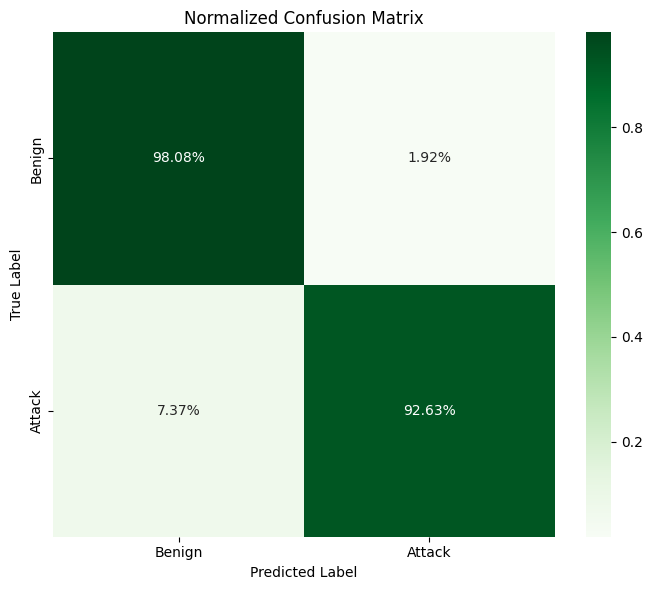

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
#y_true = graph.y[graph.test_mask].cpu().numpy()

# Predicted labels
#y_pred = pred[graph.test_mask].cpu().numpy()

# Confusion matrix
cm = confusion_matrix(y_true, pred)

# Normalize row-wise
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

In [30]:
attack_types = data["attack_type"].values

results = []

for attack in ["DDoS_20K", "DoS_20K", "Mirai_20K", "Recon_20K", "Spoofing_20K"]:

    idx = (attack_types == attack)

    total = idx.sum()

    detected = ((pred == 1) & idx).sum()

    missed = ((pred == 0) & idx).sum()

    recall = detected / total

    results.append([
        attack,
        total,
        detected,
        missed,
        recall * 100
    ])

import pandas as pd

attack_results = pd.DataFrame(
    results,
    columns=[
        "Attack",
        "Total",
        "Detected",
        "Missed",
        "Recall_%"
    ]
)

print("\n===== ATTACK DETECTION BREAKDOWN =====\n")
print(attack_results)


===== ATTACK DETECTION BREAKDOWN =====

         Attack  Total  Detected  Missed  Recall_%
0      DDoS_20K   2000      1982      18     99.10
1       DoS_20K   2000      1980      20     99.00
2     Mirai_20K   2000      1823     177     91.15
3     Recon_20K   2000      1732     268     86.60
4  Spoofing_20K   2000      1746     254     87.30


In [31]:
attack_results["Recall_%"] = attack_results["Recall_%"].round(3)

print(
    attack_results.sort_values(
        "Recall_%",
        ascending=False
    )
)

         Attack  Total  Detected  Missed  Recall_%
0      DDoS_20K   2000      1982      18     99.10
1       DoS_20K   2000      1980      20     99.00
2     Mirai_20K   2000      1823     177     91.15
4  Spoofing_20K   2000      1746     254     87.30
3     Recon_20K   2000      1732     268     86.60


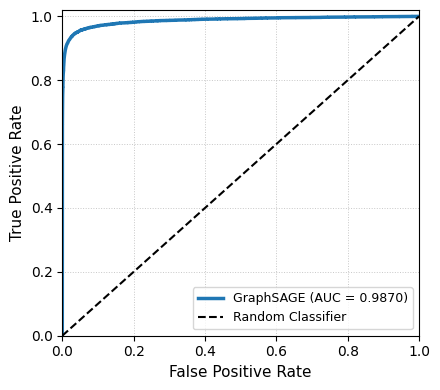

AUC Score : 0.9870


In [32]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

# ----------------------------
# Model Inference
# ----------------------------
model.eval()

with torch.no_grad():

    logits = model(
        graph.x.to(device),
        graph.edge_index.to(device)
    )

# Flow node predictions only
flow_logits = logits[:num_flow_nodes]

# Probability of Attack class
attack_prob = torch.softmax(
    flow_logits,
    dim=1
)[:, 1].cpu().numpy()

# Ground truth labels
labels = graph.y[:num_flow_nodes].cpu().numpy()

# ----------------------------
# ROC & AUC
# ----------------------------
fpr, tpr, _ = roc_curve(
    labels,
    attack_prob
)

roc_auc = auc(
    fpr,
    tpr
)

# ----------------------------
# IEEE Style Plot
# ----------------------------
plt.figure(figsize=(4.5, 4.0))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"GraphSAGE (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Random Classifier"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.xlabel(
    "False Positive Rate",
    fontsize=11
)

plt.ylabel(
    "True Positive Rate",
    fontsize=11
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    linestyle=":",
    linewidth=0.7,
    alpha=0.7
)

plt.legend(
    loc="lower right",
    fontsize=9,
    frameon=True
)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "ROC_GraphSAGE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"AUC Score : {roc_auc:.4f}")